# 02 — CPU rate, and the ladder it implies

Test plan cell **CPU CON DP + CON BP** (`pruebas-v1.xlsx`, row 6).

A 200-point ladder on CPU takes days, so this notebook does not run one. It
measures the **per-sweep cost** and extrapolates, which is exact rather than
fitted: cost is strictly linear in sweeps.

Measured on Modal (`cpu=8.0`, JAX 0.10.2), on the same image as the H100 runs,
with the full production protocol — 10,000 thermalisation + 5,000 measurement
sweeps per temperature, every observable computed. Not on a laptop: a ratio
between a local machine under WSL2 and a cloud H100 is not reproducible.

    modal run app.py::rate --config cfg_A_200T.json --tag cpu_rate_8core \
        --n-temps 4 --n-therm 60 --n-meas 40 --reps 1,25,50,100,200

Full write-up: `docs/10_ablation_and_cpu_rate.md`.


In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt

# Beside this notebook when run in place; the repo-relative path is for Kaggle
# and for execution from the repository root.
RES = next(p for p in (pathlib.Path("results"),
                       pathlib.Path("notebooks/simulation/results"),
                       pathlib.Path("/kaggle/input")) if p.exists())

def load(name):
    return json.load(open(RES / f"{name}.json"))

LADDER = 200 * (10_000 + 5_000)   # the production protocol: 3,000,000 sweeps
print(f"production ladder = {LADDER:,} sweeps")


production ladder = 3,000,000 sweeps


## Replica scaling — the CPU does not saturate like the GPU

24 threads · JAX 0.10.2 · 5245 active sites

 replicas   ms/sweep   us/replica-sweep
        1       7.43             7428.1
       25      32.27             1290.9
       50      66.60             1332.0
      100      97.43              974.3
      200     167.30              836.5


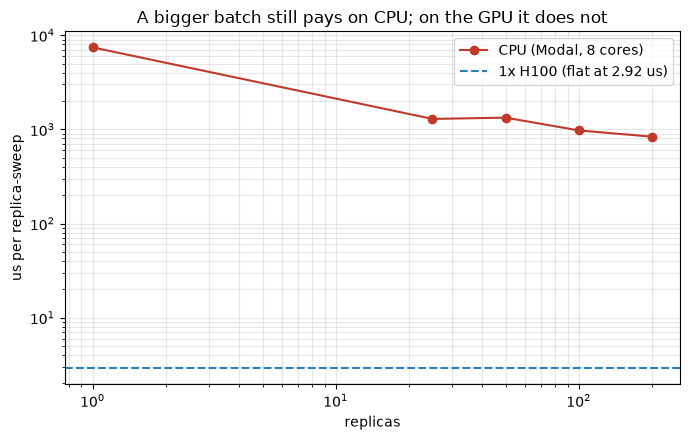

In [2]:
r = load("cpu_rate_8core")
print(f"{r['threads']} threads · JAX {r['jax_version']} · {r['n_active']} active sites\n")
print(f"{'replicas':>9} {'ms/sweep':>10} {'us/replica-sweep':>18}")
for row in r["rows"]:
    print(f"{row['replicas']:9d} {row['ms_per_sweep']:10.2f} "
          f"{row['us_per_replica_sweep']:18.1f}")

# On one H100 the per-replica cost was FLAT at 2.92 +- 0.25 us from 25 replicas
# to 400: the device is already full at 25. On CPU it keeps falling.
GPU_PER_REPLICA_US = 2.92
rep = [x["replicas"] for x in r["rows"]]
cpu = [x["us_per_replica_sweep"] for x in r["rows"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(rep, cpu, "o-", color="#c0392b", label="CPU (Modal, 8 cores)")
ax.axhline(GPU_PER_REPLICA_US, ls="--", color="#2980b9",
           label=f"1x H100 (flat at {GPU_PER_REPLICA_US} us)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("replicas"); ax.set_ylabel("us per replica-sweep")
ax.set_title("A bigger batch still pays on CPU; on the GPU it does not")
ax.grid(True, which="both", alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## The rate depends on how warm the container is

Within one container the rate improves **monotonically** as frequency, page
cache and allocator settle. Every single-shot measurement is therefore biased
high, and the ~2x spread across containers is mostly that bias rather than
hardware variation.

The production ladder is **one call lasting tens of hours**, so it runs warm
essentially throughout. The warm steady state is the figure the extrapolation
needs.

four repeats inside ONE container, in order:
  67.5, 63.6, 61.8, 56.5 ms/sweep
  -> warm steady state 62.4 +- 4.0 ms/sweep
  -> improves 16% over four repeats

first measurement in separate containers:
  79.0, 94.4, 97.4, 101.6 ms/sweep


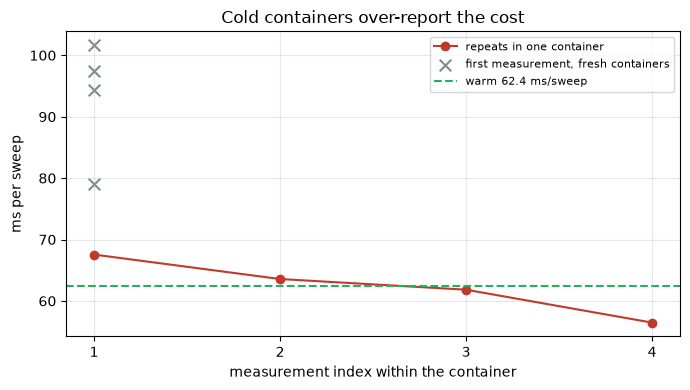

In [3]:
warm = [x["ms_per_sweep"] for x in load("cpu_rate_repeat")["rows"]]
cold = []
for i in (1, 2, 3, 4):
    try:
        cold += [x["ms_per_sweep"] for x in load(f"cpu_sample_{i}")["rows"]]
    except FileNotFoundError:
        pass
cold.append(load("cpu_rate_8core")["rows"][3]["ms_per_sweep"])  # 100 replicas

print("four repeats inside ONE container, in order:")
print("  " + ", ".join(f"{v:.1f}" for v in warm) + " ms/sweep")
print(f"  -> warm steady state {np.mean(warm):.1f} +- {np.std(warm):.1f} ms/sweep")
print(f"  -> improves {100*(warm[0]-warm[-1])/warm[0]:.0f}% over four repeats\n")
print("first measurement in separate containers:")
print("  " + ", ".join(f"{v:.1f}" for v in sorted(cold)) + " ms/sweep")

WARM = float(np.mean(warm)); WARM_SD = float(np.std(warm))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(warm) + 1), warm, "o-", color="#c0392b",
        label="repeats in one container")
ax.scatter([1] * len(cold), cold, marker="x", s=70, color="#7f8c8d",
           label="first measurement, fresh containers")
ax.axhline(WARM, ls="--", color="#27ae60", label=f"warm {WARM:.1f} ms/sweep")
ax.set_xlabel("measurement index within the container")
ax.set_ylabel("ms per sweep"); ax.set_xticks(range(1, len(warm) + 1))
ax.set_title("Cold containers over-report the cost")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## The ladder, extrapolated

In [4]:
# ms/sweep at 100 replicas. The GPU rows come from the H100 scaling study.
PATHS = [("1x H100, no decomposition", load("gpu_sitewise_h100")["ms_per_sweep"]),
         ("notebook 00 CPU mode (site-by-site)",
          [r for r in load("ablation_8core_v2")["sitewise_batched"]
           if r["batch"] == 100][0]["ms_per_sweep"]),
         ("production kernel, JAX on CPU (warm)", WARM),
         ("1x H100", 0.303), ("2x H100", 0.133), ("4x H100", 0.084)]

def human(h):
    if h > 8760:  return f"{h/8760:.1f} years"
    if h > 48:    return f"{h/24:.1f} days"
    if h < 1:     return f"{h*60:.1f} min"
    return f"{h:.1f} h"

print(f"{'path':40s} {'ms/sweep':>11} {'full ladder':>13} {'vs CPU':>9}")
for name, ms in PATHS:
    h = ms * LADDER / 3.6e6
    print(f"{name:40s} {ms:11.3f} {human(h):>13} {WARM/ms:>8.1f}x")
print(f"\nCPU ladder: {WARM*LADDER/3.6e6:.0f} +- {WARM_SD*LADDER/3.6e6:.0f} h")
print(f"1x H100 is {WARM/0.303:.0f}x the CPU, with roughly +-20% on that ratio:")
print("the GPU rows were each measured once and showed ~15% scatter.")

path                                        ms/sweep   full ladder    vs CPU
1x H100, no decomposition                 121151.442    11.5 years      0.0x
notebook 00 CPU mode (site-by-site)          401.029     13.9 days      0.2x
production kernel, JAX on CPU (warm)          62.354      2.2 days      1.0x
1x H100                                        0.303      15.2 min    205.8x
2x H100                                        0.133       6.7 min    468.8x
4x H100                                        0.084       4.2 min    742.3x

CPU ladder: 52 +- 3 h
1x H100 is 206x the CPU, with roughly +-20% on that ratio:
the GPU rows were each measured once and showed ~15% scatter.


### Reading

- **52 ± 3 h** is the CPU ladder, and the figure to quote for "how long on CPU":
  the same code on a different processor.
- **1 × H100 is ~206×** the CPU. Not 265× or 322× — those used cold CPU
  measurements, which this notebook retires.
- **334 h** is what the group's own CPU path would cost, which is a different
  question (notebook 00's CPU mode is site-by-site, and 6.4× slower than the
  vectorised kernel on the same processor).
- The first row is the subject of notebook `03`: an H100 *without* matrix
  decomposition is 302× **slower** than the CPU.
